In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import numpy as np
import bilby
import pandas as pd
import sys
sys.path.append ('/Users/ghoshtathagata/Documents/cosmo_well_localized_events/models')
from mass_model import *
from redshift_model import *
from spin_model import *
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import simpson
import pickle
from sklearn.mixture import GaussianMixture

In [2]:
galaxy_data = pd.read_csv ('../../galaxy_data/data_medium.csv', sep=',')

z_all = galaxy_data['redshift_true'].to_numpy()
ra_all = galaxy_data['ra_true'].to_numpy()
dec_all = galaxy_data['dec_true'].to_numpy()
appmag_r_all = galaxy_data['mag_true_r_lsst_no_host_extinction'].to_numpy()

mask_obs = appmag_r_all<=21

z_true = z_all[mask_obs]
ra_true = ra_all[mask_obs]*np.pi/180
dec_true = dec_all[mask_obs]*np.pi/180


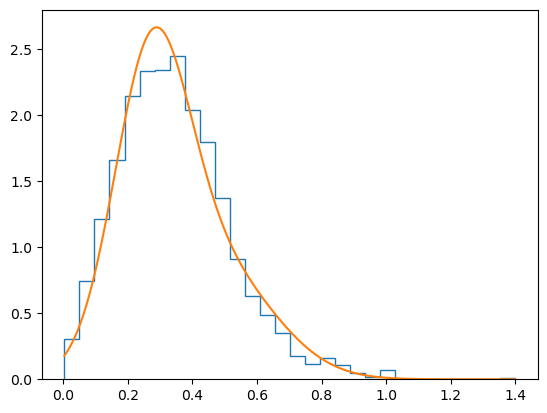

In [3]:
z_gmm = GaussianMixture(n_components=2).fit(np.column_stack ([z_true]))

z_array_entire = np.linspace (min(z_true), max(z_true), 1000)

pz_est = np.exp(z_gmm.score_samples(z_array_entire.reshape(-1, 1)))
pz_est /= simpson (x=z_array_entire, y=pz_est)

_ = plt.hist (z_true, bins=30, histtype='step', density=True)
plt.plot (z_array_entire, pz_est)

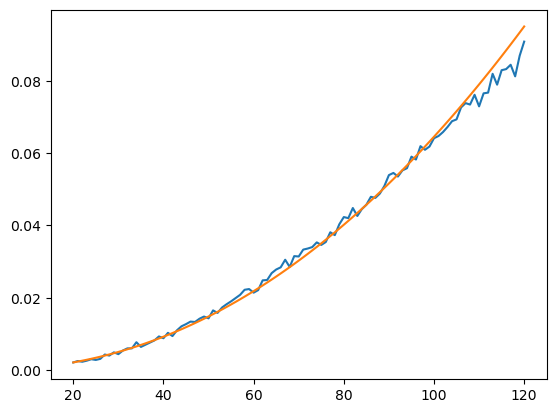

In [4]:
H0_array = np.arange (20, 121, 1)

snr_thresh = 50



with open ('../injections_10000.p', 'rb') as f:
    injections = pickle.load (f)

pdet = np.zeros (H0_array.size)

for hh, H0 in enumerate(H0_array):
    inj_H0 = injections[H0]
    inj_det_id = np.where (inj_H0>=snr_thresh) [0]
    pdet[hh] = inj_det_id.size/inj_H0.size


x = H0_array
y = pdet

# keep only positive values
mask = (x > 0) & (y > 0)

logx = np.log(x[mask])
logy = np.log(y[mask])

alpha, logA = np.polyfit(logx, logy, 1)
A = np.exp(logA)

pdet_fit = A * x**alpha


plt.plot (H0_array, pdet)
plt.plot (H0_array, pdet_fit)



Text(0.5, 0, 'SNR')

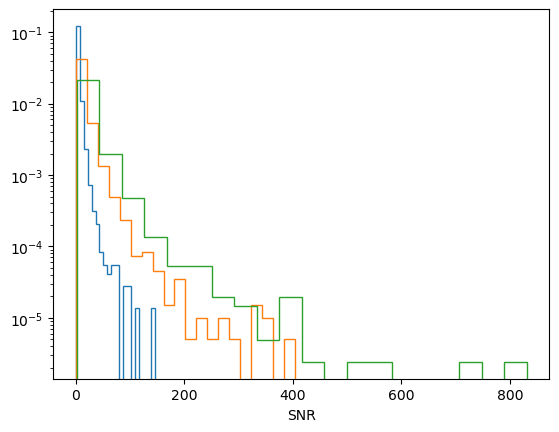

In [5]:
_ = plt.hist (injections[20], bins=20, density=True, histtype='step')
_ = plt.hist (injections[70], bins=20, density=True, histtype='step')
_ = plt.hist (injections[120], bins=20, density=True, histtype='step')

plt.yscale ('log')


plt.xlabel ('SNR')

In [6]:
parameters = pd.read_csv('GWparameters.txt', sep=' ')

dlGW = parameters['luminosity_distance'].to_numpy()
raGW = parameters['ra'].to_numpy()
decGW = parameters['dec'].to_numpy()

with open ('fim_study_1.p', 'rb') as f:
    fim = pickle.load(f)

snr = fim ['snr']
errors = fim ['errors']
sky_localization = fim ['sky_localization']

In [7]:
cosmo_true = FlatLambdaCDM (H0=70, Om0=0.3)

zref = np.linspace (0, 1.5, 1000)
dlref = cosmo_true.luminosity_distance(zref).value
dl2z = interp1d(dlref, zref)

dlGW = parameters['luminosity_distance'].to_numpy()
raGW = parameters['ra'].to_numpy()
decGW = parameters['dec'].to_numpy()
zGW = dl2z(dlGW)

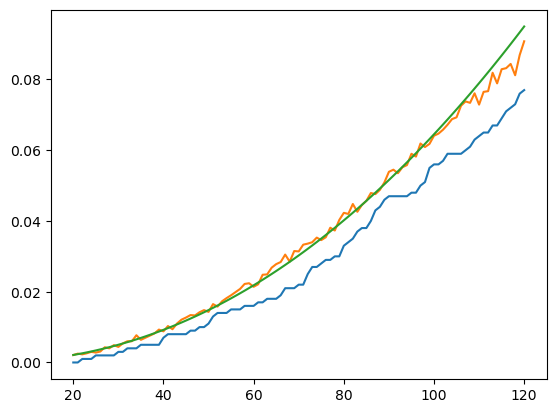

In [8]:
cosmo_true = FlatLambdaCDM (H0=70, Om0=0.3)

zref = np.linspace (0, 1.5, 1000)
dlref = cosmo_true.luminosity_distance(zref).value
dl2z = interp1d(dlref, zref)


parameters = pd.read_csv('GWparameters.txt', sep=' ')

dlGW_true = parameters['luminosity_distance'].to_numpy()
zGW_true = dl2z(dlGW)

with open ('fim_study_1.p', 'rb') as f:
    fim = pickle.load(f)

snr = fim ['snr']

selH0 = np.zeros (H0_array.size)

for hh, H0 in enumerate(H0_array):
    cosmo_H0 = FlatLambdaCDM (H0=H0, Om0=0.3)

    snr_newH0 = snr*dlGW_true/cosmo_H0.luminosity_distance(zGW_true).value
    det_test = np.where(snr_newH0>=snr_thresh) [0]
    selH0[hh] = det_test.size/snr_newH0.size


plt.plot (H0_array, selH0)

plt.plot (H0_array, pdet)
plt.plot (H0_array, pdet_fit)


In [9]:
zref = np.linspace (0, 5, 5000)

cosmo_H0min = FlatLambdaCDM (H0=H0_array[0], Om0=0.3)
dl_H0min = cosmo_H0min.luminosity_distance (zref)
dl2z_H0min = interp1d (dl_H0min, zref)

cosmo_H0max = FlatLambdaCDM (H0=H0_array[-1], Om0=0.3)
dl_H0max = cosmo_H0max.luminosity_distance (zref)
dl2z_H0max = interp1d (dl_H0max, zref)




In [10]:
with open ('fim_study_1.p', 'rb') as f:
    fim = pickle.load(f)

snr = fim ['snr']
errors = fim ['errors']

det_id = np.where(snr>=snr_thresh) [0]

In [11]:
z_sigma = 0.001 

z_array_entire = np.linspace (0, max(z_true)+3*z_sigma, 25000)

pcbc_est = np.exp(z_gmm.score_samples(z_array_entire.reshape(-1, 1)))
pcbc_est /= simpson(x=z_array_entire, y=pcbc_est)

pcbc = interp1d(z_array_entire, pcbc_est, bounds_error=False, fill_value=0.0)

pH0_array_events = np.zeros ([det_id.size, H0_array.size])

logpH0_array_comb = np.zeros (H0_array.size)

pz_gals_allevents = 0

for gg, gw_id in enumerate(tqdm(det_id)) :

    dl_1sig, ra_1sig, dec_1sig,  = errors[gw_id, :3]

    dl_min = dlGW[gw_id]-5*dl_1sig
    if dl_min<0:
        dl_min = 1e-4
    dl_max = dlGW[gw_id]+5*dl_1sig
    dl_array = np.linspace (dl_min, dl_max, 10000)

    dl_a, dl_b = (dl_min - dlGW[gw_id]) / dl_1sig, (dl_max - dlGW[gw_id]) / dl_1sig
    dl_pdf = truncnorm (dl_a, dl_b, dlGW[gw_id], dl_1sig).pdf(dl_array)

    zmin = dl2z_H0min(dl_min)
    zmax = dl2z_H0max(dl_max)

    mask_gal_in_sky = (ra_true<=raGW[gw_id]+3*ra_1sig) & (ra_true>=raGW[gw_id]-3*ra_1sig) &  (dec_true<=decGW[gw_id]+3*dec_1sig) & (dec_true>=decGW[gw_id]-3*dec_1sig) & (z_true>=zmin) & (z_true<=zmax)


    z_gal_event = z_true[mask_gal_in_sky]
    ra_gal_event = ra_true[mask_gal_in_sky]
    dec_gal_event = dec_true[mask_gal_in_sky]


    z_array = np.linspace (zmin, zmax, 10000)

    pz_gals = np.zeros (z_array.size)

    for zval in z_gal_event:
        zgal_min = zval - 3*z_sigma
        zgal_max = zval + 3*z_sigma
        if zgal_min: zgal_min=0
        z_a, z_b = (zgal_min - zval) / z_sigma, (zgal_max - zval) / z_sigma
        pz_gal = truncnorm (z_a, z_b, zval, z_sigma)
        pz_gals += pz_gal.pdf(z_array)
    pz_gals = pz_gals/z_gal_event.size

    pcbc_event = pcbc(z_array)
    
    for hh, H0 in enumerate  (H0_array) :
        cosmo_H0 = FlatLambdaCDM (H0=H0, Om0=0.3)
        dlref = cosmo_H0.luminosity_distance (zref)
        dl2z = interp1d (dlref, zref)

        zGW_array = dl2z(dl_array)
        pzGW = dl_pdf/simpson(y=dl_pdf, x=zGW_array)
        pzGW_func = interp1d(zGW_array, pzGW, bounds_error=False, fill_value=0.0)

        
        pH0_array_events [gg, hh] =  simpson(y=pzGW_func (z_array)*pz_gals*pcbc_event, x=z_array)/(H0**alpha)

    pH0_array_events [gg] /= simpson(x=H0_array, y=pH0_array_events[gg])
        


100%|██████████| 22/22 [00:40<00:00,  1.86s/it]


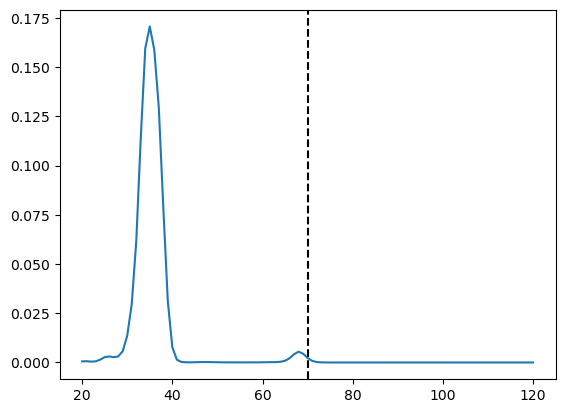

In [12]:
pH0_final = np.exp(np.sum(np.log(pH0_array_events), axis=0))
pH0_final[np.isnan(pH0_final)] = 0
pH0_final /= simpson(x=H0_array, y=pH0_final)

plt.plot( H0_array, pH0_final)

plt.axvline (70, ls='--', color='k')


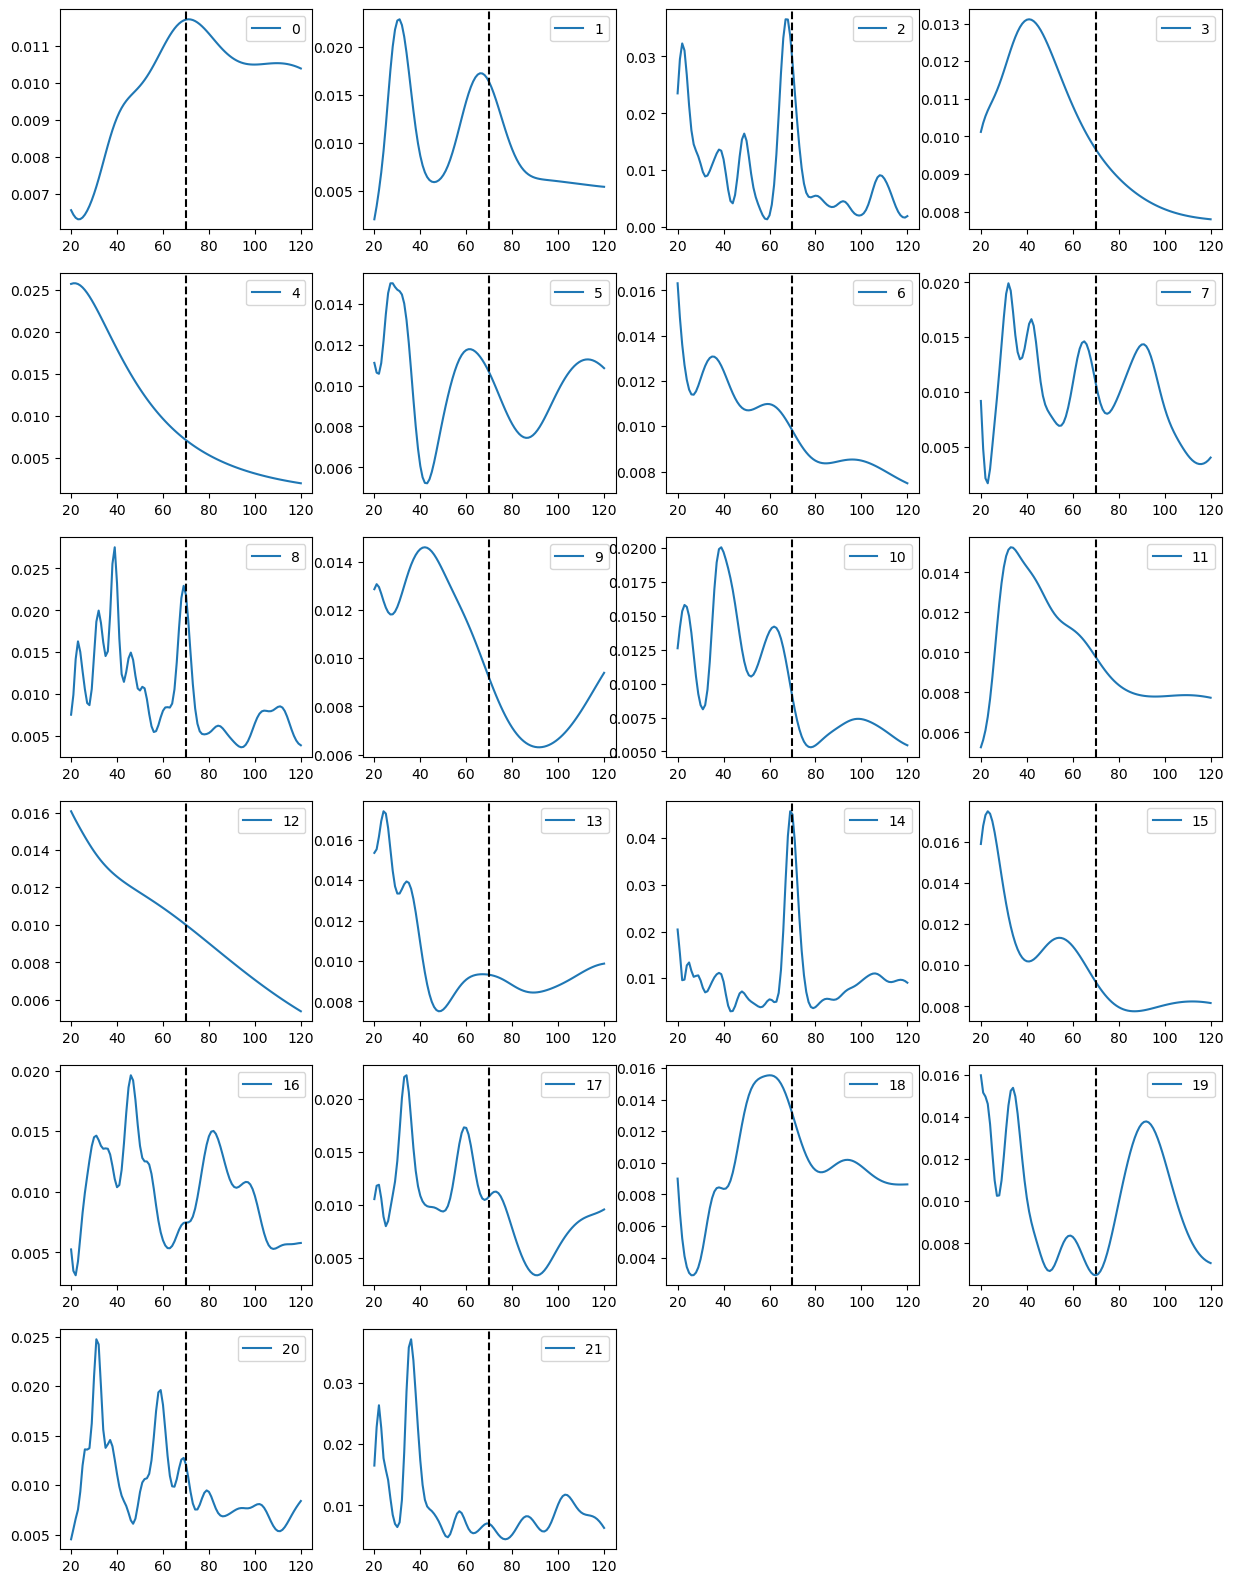

In [13]:
plt.figure (figsize=(15,20))

for ii in range (pH0_array_events.shape[0]):
    plt.subplot (6, 4, ii+1)
    plt.plot (H0_array, pH0_array_events[ii], label=ii)
    plt.axvline (70, ls='--', color='k')

    plt.legend ()